<a href="https://colab.research.google.com/github/danielbramos4/Analise-Preditiva-de-Credito-Identificando-Fatores-Chave-de-Inadimplencia/blob/main/An%C3%A1lise_Preditiva_de_Cr%C3%A9dito_Identificando_Fatores_Chave_de_Inadimpl%C3%AAncia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise Preditiva de Crédito: Identificando Fatores Chave de Inadimplência**

Este projeto de Ciência de Dados utiliza um conjunto de dados de clientes de uma instituição financeira para realizar uma Análise Exploratória de Dados (**EDA**) e identificar o perfil do cliente com maior propensão à inadimplência (**default** = 1).




Metodologia: O trabalho inclui a importação e leitura dos dados em um **dataframe Pandas** , seguido de etapas críticas de limpeza e transformação de dados (data wrangling), incluindo correção de schema e remoção de dados faltantes. A análise se aprofunda na correlação entre variáveis explicativas (como salário anual e escolaridade) e a variável resposta (default), utilizando visualizações categóricas e numéricas com **Matplotlib e Seaborn**. O objetivo final é gerar insights acionáveis que expliquem o fenômeno do default.

Perguntas a responder:
- Qual nível de escolaridade está mais associado à inadimplência?
- Existe uma faixa salarial predominante entre os clientes inadimplentes?
- Clientes inadimplentes tendem a realizar mais ou menos transações que os adimplentes?
- Onde a inadimplência se concentra no plano (Valor vs. Quantidade de Transações)?

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/develop/dataset/credito.csv', na_values='na')

In [4]:
df.head(n=10)

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,"12.691,51","1.144,90",42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,"8.256,96","1.291,45",33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,"3.418,56","1.887,72",20
3,769911858,0,40,F,4,ensino medio,NaN,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,"4.716,22","816,08",28
5,713061558,0,44,M,2,mestrado,casado,$40K - $60K,blue,36,3,2,1,"4.010,69","1.088,07",24
6,810347208,0,51,M,4,NaN,casado,$120K +,gold,46,6,3,1,"34.516,72","1.330,87",31
7,818906208,0,32,M,0,ensino medio,NaN,$60K - $80K,silver,27,2,2,2,"29.081,49","1.538,32",36
8,710930508,0,37,M,3,sem educacao formal,solteiro,$60K - $80K,blue,36,5,0,2,"22.352,50","1.350,14",24
9,719661558,0,48,M,2,mestrado,solteiro,$80K - $120K,blue,36,6,3,3,"11.656,41","1.441,73",32


In [5]:
qtdTotal, _= df.shape
qtdAdimplentes, _ = df[df['default'] == 0].shape
qtdInadimplentes, _ = df[df['default'] == 1].shape

## **Explorando os dados**

- **Proporção de clientes adimplente e inadimplentes**

In [6]:
print(f"A proporção clientes adimplentes é de {round(100 * qtdAdimplentes / qtdTotal, 2)}%")
print(f"A proporção clientes inadimplentes é de {round(100 * qtdInadimplentes / qtdTotal, 2)}%")

A proporção clientes adimplentes é de 83.93%
A proporção clientes inadimplentes é de 16.07%


- **Colunas e seus respectivos tipos de dados**

In [7]:
df.dtypes

,0
id,int64
default,int64
idade,int64
sexo,object
dependentes,int64
escolaridade,object
estado_civil,object
salario_anual,object
tipo_cartao,object
meses_de_relacionamento,int64


- **Verificando quais colunas possuem dados faltantes**

In [8]:
df.isna().any()

,0
id,False
default,False
idade,False
sexo,False
dependentes,False
escolaridade,True
estado_civil,True
salario_anual,True
tipo_cartao,False
meses_de_relacionamento,False


## **Transformação e limpeza de dados**

Corrigindo o schema

Na etapa de exploração, notamos que as colunas limite_credito e valor_transacoes_12m estavam sendo interpretadas como colunas categóricas(dtype = object)

In [9]:
df[['limite_credito', 'valor_transacoes_12m']].dtypes

,0
limite_credito,object
valor_transacoes_12m,object


In [10]:
df[['limite_credito', 'valor_transacoes_12m']].head(n=5)

,limite_credito,valor_transacoes_12m
0,"12.691,51","1.144,90"
1,"8.256,96","1.291,45"
2,"3.418,56","1.887,72"
3,"3.313,03","1.171,56"
4,"4.716,22","816,08"


- **Função lambda para limpar os dados e teste da aplicação através do método funcional map**

In [11]:
fn = lambda valor: float(valor.replace(".", "").replace(",", "."))
valoresOriginais = ['12.691,51', '8.256,96', '3.418,56', '4.716,22']
valoresLimpos = list(map(fn, valoresOriginais))

print(valoresOriginais)
print(valoresLimpos)

['12.691,51', '8.256,96', '3.418,56', '4.716,22']
[12691.51, 8256.96, 3418.56, 4716.22]


- **Aplicando a função lambda nas colunas 'valor_transacoes_12m' e 'limite_credito'**

In [12]:
df['valor_transacoes_12m'] = df['valor_transacoes_12m'].apply(fn)
df['limite_credito'] = df['limite_credito'].apply(fn)

In [13]:
df.dtypes

,0
id,int64
default,int64
idade,int64
sexo,object
dependentes,int64
escolaridade,object
estado_civil,object
salario_anual,object
tipo_cartao,object
meses_de_relacionamento,int64


- **Remoção dos dados faltantes**

In [14]:
df.dropna(inplace=True)

Analisando a estrutura dos dados novamente

In [15]:
qtd_total_novo, _ = df.shape
qtd_adimplentes_novo, _ = df[df['default'] == 0].shape
qtd_inadimplentes_novo, _ = df[df['default'] == 1].shape

In [16]:
print(f"A proporcão adimplentes ativos é de {round(100 * qtdAdimplentes / qtdTotal, 2)}%")
print(f"A nova proporcão de clientes adimplentes é de {round(100 * qtd_adimplentes_novo / qtd_total_novo, 2)}%")
print("")
print(f"A proporcão clientes inadimplentes é de {round(100 * qtdInadimplentes / qtdTotal, 2)}%")
print(f"A nova proporcão de clientes inadimplentes é de {round(100 * qtd_inadimplentes_novo / qtd_total_novo, 2)}%")

A proporcão adimplentes ativos é de 83.93%
A nova proporcão de clientes adimplentes é de 84.28%

A proporcão clientes inadimplentes é de 16.07%
A nova proporcão de clientes inadimplentes é de 15.72%


## **Visualização de dados**

In [17]:
sns.set_style("whitegrid")

In [18]:
df_adimplente = df[df['default'] == 0]
df_inadimplente = df[df['default'] == 1]

**Visualização categóricas**

- **Escolaridade**

/tmp/ipykernel_5087/3247287735.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)
/tmp/ipykernel_5087/3247287735.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)
/tmp/ipykernel_5087/3247287735.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)


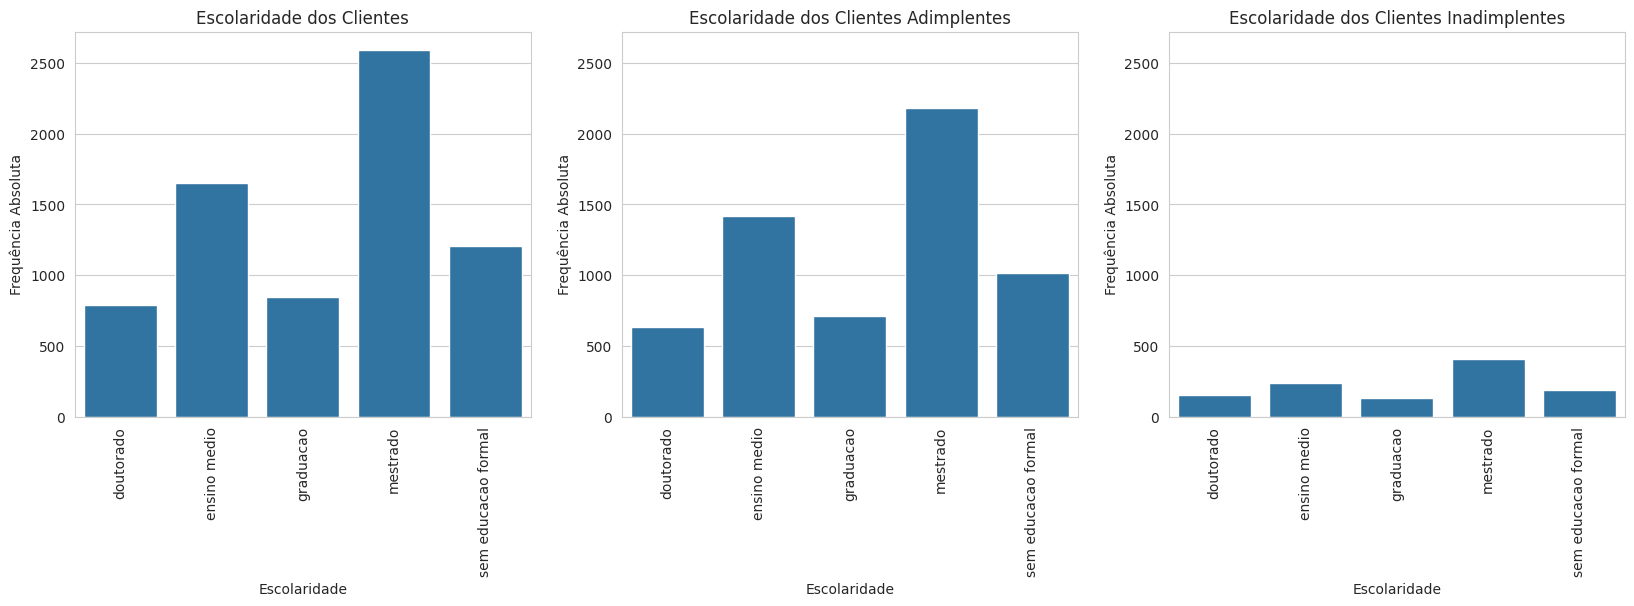

In [19]:
coluna = 'escolaridade'
titulos = ['Escolaridade dos Clientes', 'Escolaridade dos Clientes Adimplentes', 'Escolaridade dos Clientes Inadimplentes']

eixo = 0
max_y = 0
figura, eixos = plt.subplots(1,3, figsize=(20, 5), sharex=True)

for dataframe in [df, df_adimplente, df_inadimplente]:
    df_to_plot = dataframe[coluna].value_counts().reset_index()
    df_to_plot.columns = [coluna, 'frequencia_absoluta']
    df_to_plot.sort_values(by=[coluna], inplace=True)

    f = sns.barplot(x=df_to_plot[coluna], y=df_to_plot['frequencia_absoluta'], ax=eixos[eixo])
    f.set(title=titulos[eixo], xlabel=coluna.capitalize(), ylabel='Frequência Absoluta')
    f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)
    _, max_y_f = f.get_ylim()
    max_y = max_y_f if max_y_f > max_y else max_y
    f.set(ylim=(0, max_y))

    eixo += 1

figura.show()

 Os clientes com nível de escolaridade 'Mestrado' representam a maior fatia do grupo de inadimplentes.

- **Salário anual**

/tmp/ipykernel_5087/2103672059.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)
/tmp/ipykernel_5087/2103672059.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)
/tmp/ipykernel_5087/2103672059.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)


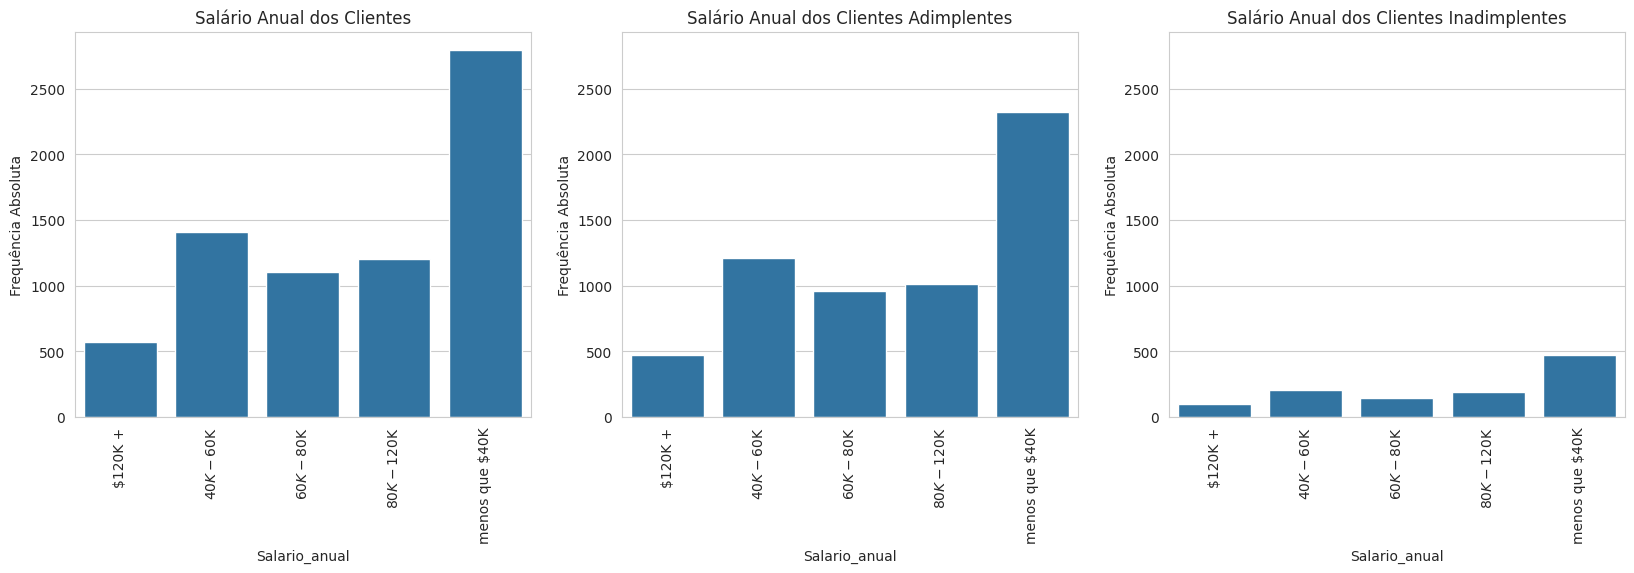

In [20]:
coluna = 'salario_anual'
titulos = ['Salário Anual dos Clientes', 'Salário Anual dos Clientes Adimplentes', 'Salário Anual dos Clientes Inadimplentes']

eixo = 0
max_y = 0
figura, eixos = plt.subplots(1,3, figsize=(20, 5), sharex=True)

for dataframe in [df, df_adimplente, df_inadimplente]:
    df_to_plot = dataframe[coluna].value_counts().reset_index()
    df_to_plot.columns = [coluna, 'frequencia_absoluta']
    df_to_plot.sort_values(by=[coluna], inplace=True)

    f = sns.barplot(x=df_to_plot[coluna], y=df_to_plot['frequencia_absoluta'], ax=eixos[eixo])
    f.set(title=titulos[eixo], xlabel=coluna.capitalize(), ylabel='Frequência Absoluta')
    f.set_xticklabels(labels=f.get_xticklabels(), rotation=90)
    _, max_y_f = f.get_ylim()
    max_y = max_y_f if max_y_f > max_y else max_y
    f.set(ylim=(0, max_y))

    eixo += 1

figura.show()

Clientes na faixa salarial mais baixa (Menos de $40K) têm uma frequência significativamente maior de inadimplência.

**Visualização numéricas**

In [21]:
df.drop(['id', 'default'], axis=1).select_dtypes('number').head(n=5)

,idade,dependentes,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,45,3,39,5,3,1,12691.51,1144.90,42
1,49,5,44,6,2,1,8256.96,1291.45,33
2,51,3,36,4,0,1,3418.56,1887.72,20
4,40,3,21,5,0,1,4716.22,816.08,28
5,44,2,36,3,2,1,4010.69,1088.07,24


- **Quantidade de transações nos ultimos 12 meses**

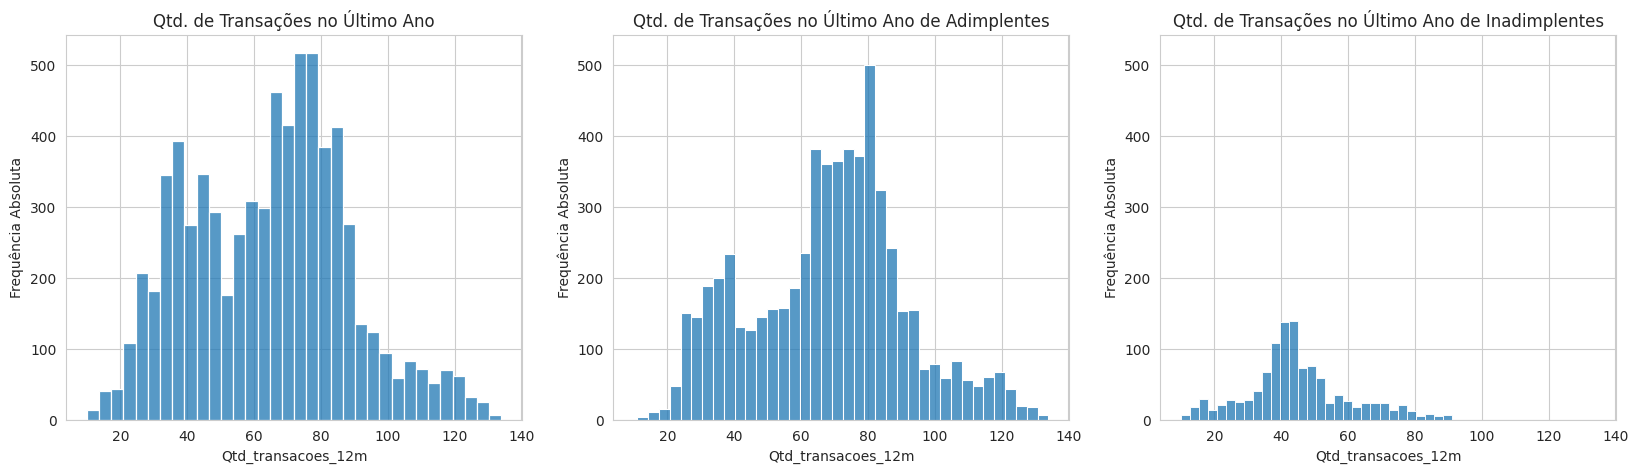

In [22]:
coluna = 'qtd_transacoes_12m'
titulos = ['Qtd. de Transações no Último Ano', 'Qtd. de Transações no Último Ano de Adimplentes', 'Qtd. de Transações no Último Ano de Inadimplentes']

eixo = 0
max_y = 0
figura, eixos = plt.subplots(1,3, figsize=(20, 5), sharex=True)

for dataframe in [df, df_adimplente, df_inadimplente]:

  f = sns.histplot(x=coluna, data=dataframe, stat='count', ax=eixos[eixo])
  f.set(title=titulos[eixo], xlabel=coluna.capitalize(), ylabel='Frequência Absoluta')

  _, max_y_f = f.get_ylim()
  max_y = max_y_f if max_y_f > max_y else max_y
  f.set(ylim=(0, max_y))

  eixo += 1

figura.show()

O histograma para inadimplentes pode mostrar que eles se concentram em um número muito menor de transações anuais, enquanto os adimplentes têm uma distribuição mais ampla ou mais alta.

- **Valor de transações nos ultimos 12 meses x Quantidade de transações no ultimos 12 meses**

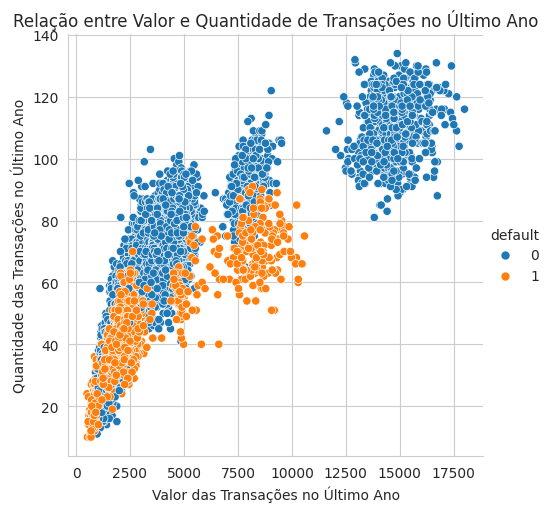

In [23]:
f = sns.relplot(x='valor_transacoes_12m', y='qtd_transacoes_12m', data=df, hue='default')
_ = f.set(
    title='Relação entre Valor e Quantidade de Transações no Último Ano',
    xlabel='Valor das Transações no Último Ano',
    ylabel='Quantidade das Transações no Último Ano')

O gráfico de dispersão mostra que os clientes inadimplentes (default = 1) formam um cluster de pontos concentrados na região de baixo valor e baixa quantidade de transações, claramente separados do cluster de clientes adimplentes (default = 0).

## **Machine Learning: Predição de Inadimplência**

Para avançarmos na nossa análise, vamos construir um modelo preditivo utilizando o algoritmo **Random Forest**. O objetivo é prever se um cliente será inadimplente (`default = 1`) com base em seu comportamento e perfil, além de descobrir quais fatores pesam mais nessa decisão.


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df.drop(['id', 'default'], axis=1)
y = df['default']

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados preparados com sucesso!")

Dados preparados com sucesso!


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train_scaled, y_train)

previsoes = modelo_rf.predict(X_test_scaled)

print("Acurácia do Modelo: {:.2f}%\n".format(accuracy_score(y_test, previsoes) * 100))
print("Relatório de Classificação:\n", classification_report(y_test, previsoes))

Acurácia do Modelo: 92.94%

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.93      0.98      0.96      1791
           1       0.89      0.63      0.74       334

    accuracy                           0.93      2125
   macro avg       0.91      0.81      0.85      2125
weighted avg       0.93      0.93      0.92      2125



### **Quais são os principais fatores que levam à inadimplência?**

O modelo de Random Forest nos permite extrair a importância matemática de cada variável para a tomada de decisão. Vamos visualizar os 10 principais motivos.

/tmp/ipykernel_5087/502921105.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variavel', data=df_importancias.head(10), palette='viridis')


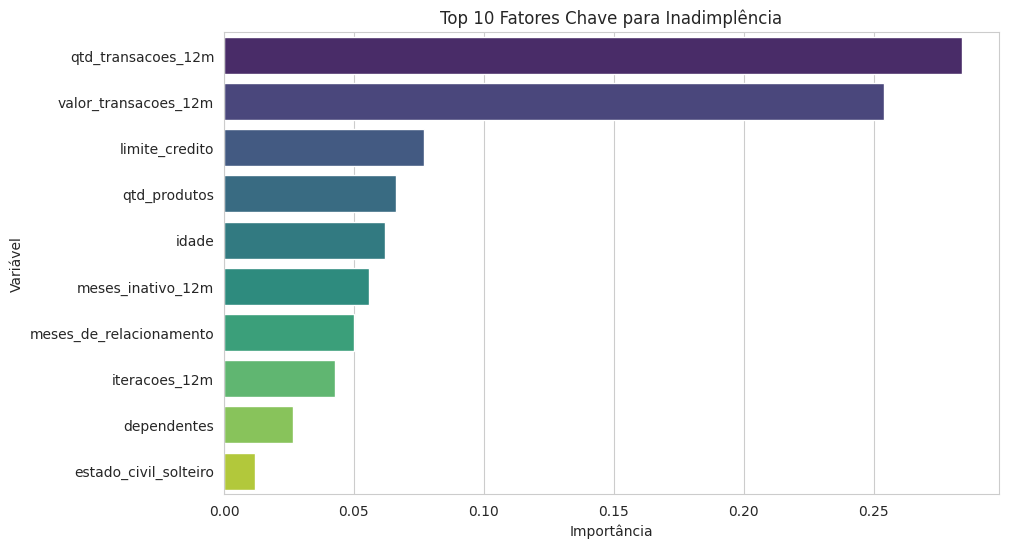

In [26]:
import numpy as np

importancias = modelo_rf.feature_importances_
features = X_encoded.columns

df_importancias = pd.DataFrame({'Variavel': features, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variavel', data=df_importancias.head(10), palette='viridis')
plt.title('Top 10 Fatores Chave para Inadimplência')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

1. Soluções para Negociações de Dívidas (Foco em inadimplentes)

- Abordagem Preventiva: Como o modelo pode prever quem vai ficar inadimplente, a instituição pode enviar SMS ou notificações no app oferecendo parcelamento da fatura com juros reduzidos antes que a fatura vença, focando nos clientes identificados pelo modelo.

- Renegociação Personalizada: Para clientes já inadimplentes com salário < $40K, criar campanhas de quitação com descontos agressivos em multas, permitindo o pagamento em mais parcelas (ex: 24x a 36x).

- Pausa no Limite: Clientes inativos há mais de 3 meses que apresentam alto risco devem ter revisões de limite preventivas, evitando que façam grandes compras que não conseguirão pagar.

2. Benefícios para Adimplentes de Alta Renda (Salário $120K+ e Cartões Gold/Platinum)

- Upgrade de Categoria e Retenção: Identificar clientes de alta renda que usam cartões "Blue" e oferecê-los upgrades gratuitos para "Gold" ou "Platinum" com isenção de anuidade no primeiro ano.

- Programa de Fidelidade Exclusivo: Clientes com alta qtd_transacoes_12m e alto valor_transacoes_12m que nunca atrasaram devem receber multiplicadores de pontos/milhas e acesso a salas VIP.

- Cross-selling (Venda Cruzada): Como eles pagam em dia, a instituição deve oferecer produtos financeiros rentáveis, como seguros residenciais, consórcios automotivos ou produtos de investimento de alta rentabilidade (CDBs, Fundos).